# Logistic Regression from Scratch 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Mock Data Generation

In [ ]:
def generate_classification_data(n_samples=200):
    X = np.random.randn(n_samples, 5)
    # True weights for linear combination
    true_weights = np.array([1.0, -2.0, 3.0, 0.5, -1.0])
    true_bias = 0.5
    
    # Linear combo
    z = X @ true_weights + true_bias

    # Sigmoid to get probability
    prob = 1 / (1 + np.exp(-z))

''    y = (prob > 0.5).astype(int)
    
    columns = [f"Feature_{i+1}" for i in range(5)]
    df = pd.DataFrame(X, columns=columns)
    df['Target'] = y
    return df, X, y

df, X, y = generate_classification_data()
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Target
0,0.792369,1.135088,-0.103863,-0.257124,0.900943,0
1,-1.714153,-0.105729,-0.153774,0.546822,0.348634,0
2,0.789857,0.068457,1.225219,0.002649,-1.706331,1
3,-0.144352,-0.787648,0.962885,0.627832,0.785503,1
4,0.129480,0.638132,1.980000,-1.782791,-1.216536,1


## 2. Logistic Regression Implementation from Scratch

Sigmoid: $\sigma(z) = \frac{1}{1 + e^{-z}}$

Cross-Entropy Loss: $L = -\frac{1}{n} \sum [y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$


In [ ]:
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            # Prediction
            z = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(z)
            
            # Gradients
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            
            # Updates
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # Loss (Cross-Entropy)
            loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
            self.loss_history.append(loss)

    def predict_prob(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_prob(X) >= threshold).astype(int)

## 3. Training the Model

In [11]:
model = LogisticRegressionGD(learning_rate=0.1, n_iterations=1000)
model.fit(X, y)

y_pred = model.predict(X)
accuracy = np.mean(y_pred == y)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 99.00%


## 4. Visualization of Results

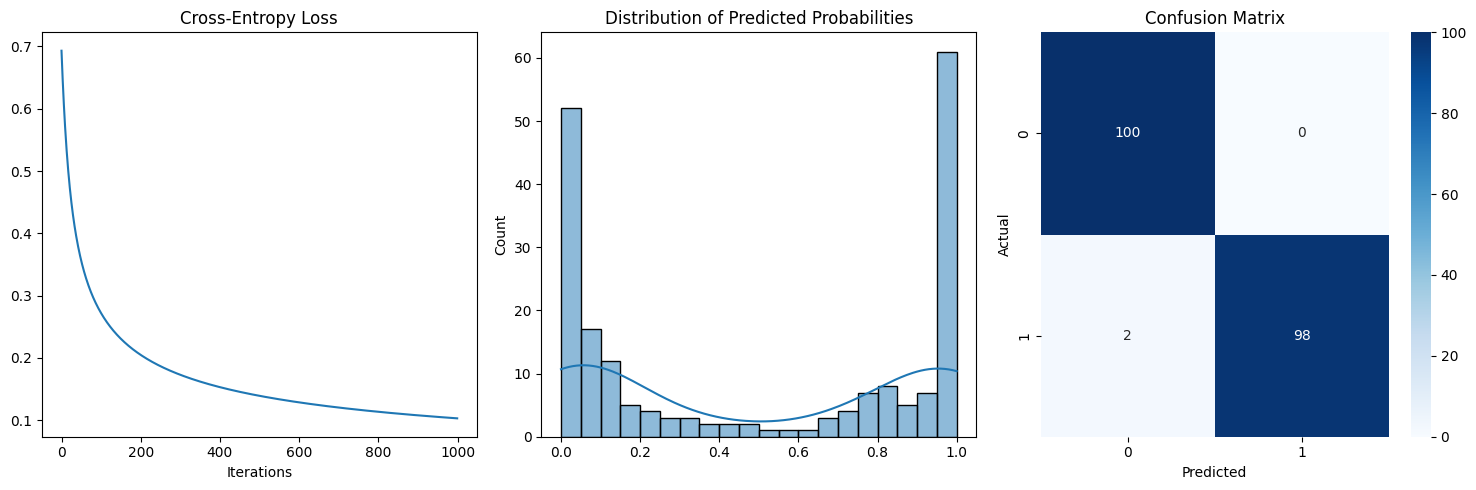

In [12]:
plt.figure(figsize=(15, 5))

# 1. Loss History
plt.subplot(1, 3, 1)
plt.plot(model.loss_history)
plt.title("Cross-Entropy Loss")
plt.xlabel("Iterations")

# 2. Prediction Probabilities
plt.subplot(1, 3, 2)
sns.histplot(model.predict_prob(X), bins=20, kde=True)
plt.title("Distribution of Predicted Probabilities")

# 3. Confusion Matrix 'Like' Visualization
plt.subplot(1, 3, 3)
results_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
sns.heatmap(pd.crosstab(results_df['Actual'], results_df['Predicted']), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()